# PharmaTrade-MM Phase 2: Trading Environment Sanity Check

This notebook validates the Phase 2 Gym environment built in `phase2_trading_env.py`.

It performs:
- environment construction from processed Phase 1 files
- reset and observation/action space checks
- random-policy rollout over one episode
- simple performance diagnostics (portfolio value path, daily return stats)


In [8]:

%pip install gymnasium matplotlib



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import numpy as np
import pandas as pd

# Optional plotting
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False
    print("matplotlib not installed; plot cells will print text summaries only.")

from phase2_trading_env import make_env_from_processed, DEFAULT_TICKERS


In [10]:
DATASET_PATH = "processed/train_dataset.csv"
FEATURE_CONFIG_PATH = "processed/feature_config.json"

env = make_env_from_processed(
    dataset_path=DATASET_PATH,
    feature_config_path=FEATURE_CONFIG_PATH,
    tickers=DEFAULT_TICKERS,
    initial_cash=1_000_000.0,
    transaction_cost=0.001,
    trade_fraction=0.10,
    event_window_scale=0.50,
    use_event_scaling=True,
)

obs, info = env.reset(seed=42)
print("Environment created")
print("Observation shape:", obs.shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Reset info:", info)


Environment created
Observation shape: (345,)
Action space: MultiDiscrete([3 3 3 3 3 3 3 3])
Observation space: Box(-inf, inf, (345,), float32)
Reset info: {'date': '2018-02-20', 'portfolio_value': 1000000.0, 'cash': 1000000.0}


## Clinical Trial (`ct_*`) Feature Diagnostics

This section verifies that the new clinical-trial features are present and non-trivial in the training data.

In [11]:
# Make this cell runnable independently.
if "train_df" not in globals():
    dataset_path = globals().get("DATASET_PATH", "processed/train_dataset.csv")
    train_df = pd.read_csv(dataset_path, parse_dates=["date"])

ct_cols = [c for c in train_df.columns if c.startswith("ct_")]
print("Clinical trial feature columns:", ct_cols)

if not ct_cols:
    print("No ct_* features found. Check Phase 1 pipeline output and feature config.")
else:
    # Coverage diagnostics: how often each feature is non-zero
    nz = (
        (train_df[ct_cols] > 0)
        .sum()
        .to_frame("nonzero_rows")
        .assign(nonzero_pct=lambda d: 100 * d["nonzero_rows"] / len(train_df))
        .sort_values("nonzero_rows", ascending=False)
    )
    display(nz)

    # Basic distribution summary for report
    summary = train_df[ct_cols].describe().T[["mean", "std", "min", "50%", "max"]]
    display(summary)

    # Per-ticker average activity
    per_ticker = train_df.groupby("ticker")[ct_cols].mean().sort_index()
    display(per_ticker)

Clinical trial feature columns: []
No ct_* features found. Check Phase 1 pipeline output and feature config.


In [12]:
# Random policy rollout for one episode
obs, info = env.reset(seed=123)
portfolio_values = [info["portfolio_value"]]
daily_returns = []
rewards = []
dates = [info["date"]]

done = False
steps = 0
while not done:
    action = env.action_space.sample()
    obs, reward, done, _, step_info = env.step(action)
    rewards.append(float(reward))
    daily_returns.append(float(step_info["daily_return"]))
    portfolio_values.append(float(step_info["portfolio_value"]))
    dates.append(step_info["date"])
    steps += 1

print(f"Episode steps: {steps}")
print(f"Start value: {portfolio_values[0]:,.2f}")
print(f"End value:   {portfolio_values[-1]:,.2f}")
print(f"Total return: {(portfolio_values[-1]/portfolio_values[0]-1)*100:.2f}%")
print(f"Mean daily return: {np.mean(daily_returns):.6f}")
print(f"Std daily return:  {np.std(daily_returns):.6f}")
print(f"Mean reward:       {np.mean(rewards):.6f}")


Episode steps: 975
Start value: 1,000,000.00
End value:   1,282,797.37
Total return: 28.28%
Mean daily return: -0.000060
Std daily return:  0.000021
Mean reward:       -0.007306


In [13]:
# Summary table for report
summary = pd.DataFrame({
    "metric": [
        "episode_steps",
        "start_value",
        "end_value",
        "total_return_pct",
        "mean_daily_return",
        "std_daily_return",
        "mean_reward",
    ],
    "value": [
        len(daily_returns),
        portfolio_values[0],
        portfolio_values[-1],
        (portfolio_values[-1]/portfolio_values[0]-1)*100,
        float(np.mean(daily_returns)),
        float(np.std(daily_returns)),
        float(np.mean(rewards)),
    ]
})
summary


,metric,value
0,episode_steps,9.750000e+02
1,start_value,1.000000e+06
2,end_value,1.282797e+06
3,total_return_pct,2.827974e+01
4,mean_daily_return,-6.044667e-05
5,std_daily_return,2.060940e-05
6,mean_reward,-7.306107e-03


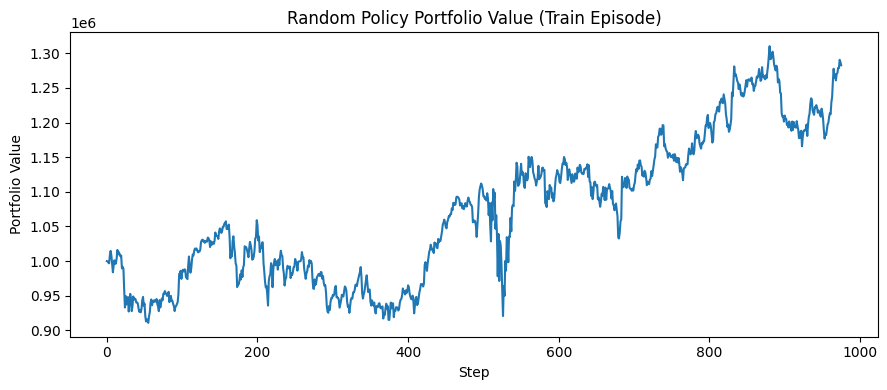

In [14]:
# Optional plot for sanity check
if HAS_MATPLOTLIB:
    plt.figure(figsize=(9, 4))
    plt.plot(portfolio_values)
    plt.title("Random Policy Portfolio Value (Train Episode)")
    plt.xlabel("Step")
    plt.ylabel("Portfolio Value")
    plt.tight_layout()
    plt.show()
else:
    print("Plot skipped (matplotlib not installed).")
